# Task 2A - 01 Data audit
**Question:** can the supplied files be turned into a clean weekly depot x brand demand history, and what does the 10-week forecast window look like?

Booklet rules we audit against: every order counts once (incl. `deferred`, `not_run`); week = week the store *requested* the order (`order_date`); weeks come from `calendar.csv` ISO fields; only Fresh has chilled demand.

In [1]:
import sys, warnings; warnings.filterwarnings('ignore')
sys.path.append('../../tools/task2a')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib, json
from task2a_common import *
from task2a_features import *
from task2a_models import *
from task2a_validation import *
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 50); pd.set_option('display.max_rows', 100)
plt.rcParams.update({'figure.dpi': 90, 'axes.grid': True, 'grid.alpha': .25})
for d in (INTERIM, METRICS, FIGURES): d.mkdir(parents=True, exist_ok=True)
o, cal = load_orders(); cal2 = enrich_calendar(cal); panel = build_panel(o, cal2)


## 1. Sources and coverage

In [6]:
print(o.groupby('src').agg(rows=('delivery_id', 'size'), first=('date', 'min'), last=('date', 'max'), days=('date', 'nunique')))
print('duplicate delivery_id:', o.delivery_id.duplicated().sum())
print('train/test overlap days:', len(set(o[o.src == 'train'].date) & set(o[o.src == 'test'].date)))
print(pd.crosstab(o.src, o.dispatch_status))
last_train, first_test = o[o.src == 'train'].date.max(), o[o.src == 'test'].date.min()
gap = cal[(cal.date > last_train) & (cal.date < first_test)][['date', 'dow_name', 'is_operating']]
print('\ncalendar days between train end and test start (must be non-operating):'); print(gap)

        rows      first       last  days
src                                     
test    5014 2026-02-16 2026-03-28    36
train  92307 2024-01-01 2026-02-14   659
duplicate delivery_id: 0
train/test overlap days: 0
dispatch_status  attempted  deferred  not_run
src                                          
test                  4924        90        0
train                90351      1543      413

calendar days between train end and test start (must be non-operating):
          date dow_name  is_operating
776 2026-02-15      Sun             0


**Finding.** Train ends 2026-02-14 (Sat) and the Task 1 test file starts 2026-02-16 (Mon); the only day between is a Sunday. Stacking the two gives a gap-free history up to 2026-03-28 = end of ISO week 13, so the forecast (weeks 14-23) starts immediately after the data. The test file has **no `not_run` orders** (it only holds dispatched orders), which biases its weeks slightly low - handled in notebook 02.

## 2. Orders vs operating days

In [8]:
m = o.merge(cal[['date', 'is_operating', 'dow', 'iso_year', 'iso_week']], on='date', how='left')
print('orders with no calendar row:', m.is_operating.isna().sum())
print('orders on NON-operating days:', int((m.is_operating == 0).sum()), '| on Sundays:', int((m.dow == 6).sum()))
ops = cal2[(cal2.is_operating == 1) & (cal2.date <= o.date.max())]
z = []
for dep, b in SERIES:
    have = set(o[(o.depot == dep) & (o.brand == b)].date)
    z.append((dep, b, len(ops), int(ops.date.isin(have).sum()), int((~ops.date.isin(have)).sum())))
print(pd.DataFrame(z, columns=['depot', 'brand', 'operating_days', 'days_with_orders', 'days_without_orders']))

orders with no calendar row: 0
orders on NON-operating days: 0 | on Sundays: 0
        depot  brand  operating_days  days_with_orders  days_without_orders
0       Kandy  Fresh             695               695                    0
1       Kandy  Style             695               462                  233
2       Kandy   Tech             695               406                  289
3  Peliyagoda  Fresh             695               695                    0
4  Peliyagoda  Style             695               463                  232
5  Peliyagoda   Tech             695               471                  224


**Finding.** No order falls on a non-operating day and nothing is shifted onto the next operating day (checked in notebook 03), so forecasts must be produced for *operating days only* and summed. Fresh orders every operating day; Style and Tech have days without orders, which are genuine zeros, not missing data.

## 3. The order schedule is (almost) deterministic

In [9]:
d = o.groupby(['depot', 'brand', 'date']).size().reset_index(name='n'); d['dow'] = d.date.dt.dayofweek
print('orders per day by weekday (mean over days with at least one order):')
print(d.groupby(['depot', 'brand', 'dow']).n.mean().unstack().round(1))
print('\nstd of orders/day for Fresh (tiny -> fixed schedule):'); print(d[d.brand == 'Fresh'].groupby(['depot', 'dow']).n.std().unstack().round(2))
s = o[o.brand != 'Fresh'].assign(dow=lambda x: x.date.dt.dayofweek)
print('\nshare of orders by weekday - Style/Tech follow depot-specific weekdays:'); print(pd.crosstab([s.brand, s.depot], s.dow, normalize='index').round(2))

orders per day by weekday (mean over days with at least one order):
dow                  0     1     2     3     4     5
depot      brand                                    
Kandy      Fresh  50.0  51.0  54.0  52.0  50.0  53.0
           Style   2.0   NaN   1.0   5.0   NaN   1.0
           Tech    1.0   NaN   2.4   1.7   1.0   1.0
Peliyagoda Fresh  79.0  88.0  77.0  87.0  75.0  83.9
           Style   2.0   NaN   3.0   6.0   5.0   NaN
           Tech    1.0   3.0   1.0   NaN   3.9   2.2

std of orders/day for Fresh (tiny -> fixed schedule):
dow           0     1     2     3     4     5
depot                                        
Kandy       0.0  0.00  0.00  0.00  0.00  0.00
Peliyagoda  0.0  0.46  0.28  0.37  0.18  0.63

share of orders by weekday - Style/Tech follow depot-specific weekdays:
dow                  0     1     2     3     4     5
brand depot                                         
Style Kandy       0.22  0.00  0.11  0.55  0.00  0.11
      Peliyagoda  0.13  0.00  0.19  0

**Finding.** Order *counts* are fixed by weekday (Fresh Peliyagoda: 79/88/77/87/75/84; std < 1). Style and Tech only order on certain weekdays per depot (e.g. Kandy Tech on Wed-Fri, Peliyagoda Tech on Tue/Fri/Sat). So a 4-day holiday week loses *specific* weekdays, and the volume model needs weekday terms. The uncertain part of demand is order **size**.

## 4. The forecast window (ISO weeks 14-23 of 2026)

In [5]:
w = cal2[(cal2.iso_year == 2026) & cal2.iso_week.between(14, 23)]
tbl = w.groupby('iso_week').agg(first_day=('date', 'min'), operating_days=('is_operating', 'sum'), paydays=('is_payday', 'sum'), holidays=('is_holiday', 'sum'),
                                 mean_ramp=('festival_ramp', 'mean'), festival=('festival', lambda s: ','.join(s.dropna())))
tbl.round(2)

,first_day,operating_days,paydays,holidays,mean_ramp,festival
iso_week,,,,,,
14,2026-03-30,6,1,0,0.04,
15,2026-04-06,6,0,0,0.60,
16,2026-04-13,4,0,2,0.14,new_year
17,2026-04-20,6,1,0,0.21,
18,2026-04-27,5,1,1,0.57,vesak
19,2026-05-04,6,0,0,0.00,
20,2026-05-11,6,0,0,0.00,
21,2026-05-18,6,0,0,0.14,
22,2026-05-25,6,2,1,0.64,poson


**Finding.** The window is festival-heavy: week 15 is the Sinhala New Year run-up, week 16 is New Year week with only **4 operating days**, week 18 contains Vesak (May 1, **5 operating days**), week 22 has Poson plus two paydays. A model that ignores the calendar will be wrong exactly where it matters.

## 5. Weekly history per series

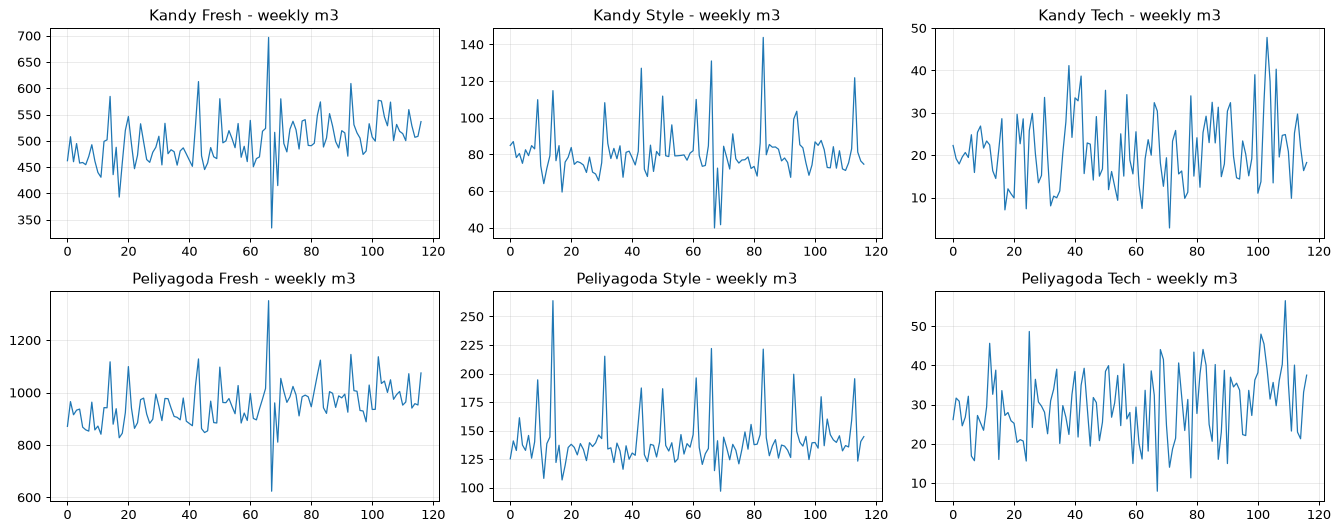

                  count   mean   std    min    25%    50%    75%     max
depot      brand                                                        
Kandy      Fresh  117.0  500.3  46.2  334.3  470.4  496.3  528.0   696.8
           Style  117.0   81.0  14.2   39.9   74.3   78.8   84.1   143.8
           Tech   117.0   21.2   8.6    2.8   15.1   20.3   25.8    47.8
Peliyagoda Fresh  117.0  956.1  85.1  623.5  898.4  947.9  994.6  1351.0
           Style  117.0  141.7  24.0   96.8  130.3  137.1  143.7   263.9
           Tech   117.0   29.8   9.0    7.9   23.0   29.7   36.5    56.5


In [6]:
wk = panel.assign(k=panel.iso_year * 100 + panel.iso_week).groupby(['depot', 'brand', 'k']).vol.sum().reset_index()
fig, axs = plt.subplots(2, 3, figsize=(15, 6))
for a, (dep, b) in zip(axs.ravel(), SERIES):
    g = wk[(wk.depot == dep) & (wk.brand == b)]
    a.plot(range(len(g)), g.vol.values, lw=1); a.set_title(f'{dep} {b} - weekly m3')
plt.tight_layout(); plt.savefig(FIGURES / '01_weekly_history.png'); plt.show()
print(wk.groupby(['depot', 'brand']).vol.describe().round(1))

## Audit conclusions
1. Data are clean: no duplicate orders, every order maps to a calendar row, no order on a non-operating day, no gap between train and test files.
2. One known defect: the Task 1 test file lacks `not_run` orders - corrected in notebook 02.
3. Demand = fixed weekday order schedule x calendar-driven order size; Tech is sparse and noisy (many zero days), Style is weekly per outlet.
4. The 10-week window contains New Year, Vesak and Poson plus short weeks, so calendar handling is the core of this task.